# visualization.ipynb

In [1]:
%matplotlib widget

import roadside as rs
import sqlite3
import textwrap
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
from icecream import ic
import numpy as np


In [2]:
# root_dir = "/home/aubrey/Desktop/sam3-2026-01-31"
image_paths = ["example_images/08hs-palms-03-zglw-superJumbo.webp"]
text_prompts=["coconut palm tree"]
db_path = 'test.db'

# Functions

## get_data_for_detections_table()

- comes from roadside.py.
- is here so that I can modify it.
- before moving back to roadside.py I need to remember to remove rs. preceding function calls.

## Required mods
- I need to find convexity defects on the crown of the coconut tree instead of the whole tree.

## Notes
- Looks like the best approach is to modify **get_data_for_detections_table()** so that the **hull_indices_string** field is for the crown and not the whole tree

In [3]:
def contour2binary_image(image_height, image_width, contour):
    img = np.zeros((image_height, image_width), dtype=np.uint8)
    return cv2.drawContours(img, [contour], -1, (255), thickness=cv2.FILLED)

# # Usage example
# sql =textwrap.dedent("""
#     select images.image_id, image_height, image_width, poly_wkt
#     from images, detections
#     where images.image_id=detections.image_id 
#     limit 1
#     """)
# df = pd.read_sql(sql, sqlite3.connect(db_path))
# for _, row in df.iterrows():
#     img = contour2binary_image(
#         image_height=row.image_height, 
#         image_width=row.image_width, 
#         contour=rs.wkt2contour(row.poly_wkt))

In [4]:
def gaussian_smooth(data, window_size):
    window = np.hanning(window_size) # Bell-shaped curve
    window /= window.sum()           # Normalize
    return np.convolve(data, window, mode='same')

# # Usage example
# sql =textwrap.dedent("""
#     select images.image_id, image_height, image_width, poly_wkt
#     from images, detections
#     where images.image_id=detections.image_id 
#     limit 1
#     """)
# df = pd.read_sql(sql, sqlite3.connect(db_path))
# for _, row in df.iterrows():
#     img = contour2binary_image(
#         image_height=row.image_height, 
#         image_width=row.image_width, 
#         contour=rs.wkt2contour(row.poly_wkt))

In [5]:
# THIS WORKS

def get_crown_mask(image_height: int, image_width: int, tree_poly_wkt: str) -> str:
    """ 
    Returns a binary mask for the crown of a detected coconut palm with the same shape as the original image.
    """
    # create a binary mask of the palm tree with the same shape as the original image
    tree_contour = rs.wkt2contour(tree_poly_wkt)
    tree_mask = contour2binary_image(image_height, image_width, tree_contour)
    
    # row_sums is an array containing the number of white pixels (value=1) for each row of the mask
    row_sums = np.sum(tree_mask, axis=1)
    
    # normalized_row_sum is the proportion of mask pixels in each row
    total_row_sums = np.sum(row_sums, dtype=np.float64)
    normalized_row_sums = row_sums / total_row_sums

    # Calculate the difference between consecutive row sums to find where the sum changes significantly
    # to_begin=0 to keep the same length as row_sums
    differences = np.ediff1d(normalized_row_sums, to_begin=0) 
    gaussian_smoothed_differences = gaussian_smooth(differences, window_size=9)

    # cut_line estimates the y-value which separates the crown from the trunk
    # the 10 rows of pixels at the bottom of the mask are ignored when finding cut_line
    threshold = -0.00002
    stop_search = -10
    cut_line = np.max(np.where(gaussian_smoothed_differences[:stop_search] < threshold)).item()
    
    # segment the crown by making all pixels black from the cut_line downwards
    crown_mask = tree_mask
    crown_mask[cut_line:,:] = 0
    
    return crown_mask


def get_crown_poly(crown_mask):
    """ 
    """
    contours, _ = cv2.findContours(crown_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        crown_poly = np.squeeze(cv2.approxPolyDP(curve=cnt, epsilon=1, closed=True))
    return crown_poly
   
 
# Usage example: 
 
sql =textwrap.dedent("""
    select image_height, image_width, poly_wkt
    from images, detections
    where images.image_id=detections.image_id 
    limit 1
    """)
df = pd.read_sql(sql, sqlite3.connect(db_path))
for _, r in df.iterrows():
    crown_mask = get_crown_mask(r.image_height, r.image_width, r.poly_wkt)
    crown_poly = get_crown_poly(crown_mask)
    crown_poly_wkt = rs.conv_poly_from_array_to_wkt(crown_poly)
    
ic(crown_poly_wkt)

ic| crown_poly_wkt: 'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 520 955, 553 956, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'


'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 520 955, 553 956, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'

In [6]:
poly_wkt = 'POLYGON((0 0, 0 40, 40 40, 40 0, 0 0))'
poly = rs.conv_poly_from_wkt_to_array(poly_wkt)
ic(poly.shape)

squeezed_crown_poly = np.squeeze(crown_poly)

ic(squeezed_crown_poly.shape)

ic| poly.shape: (5, 2)
ic| squeezed_crown_poly.shape: (81, 2)


(81, 2)

In [7]:
type(crown_poly)
rs.conv_poly_from_array_to_wkt(crown_poly)

'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 520 955, 553 956, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'

In [8]:
def find_vcuts(crown_mask):
    # my_img = cv2.imread(image_paths[0])
    # my_img = cv2.cvtColor(my_img, cv2.COLOR_RGB2BGR)
    contours, hierarchy = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        hull = cv2.convexHull(cnt)
        # # Draw original contour in green
        # cv2.drawContours(my_img, [cnt], 0, (0, 255, 0), 1)
        # # Draw convex hull in red
        # cv2.drawContours(my_img, [hull], 0, (0, 0, 255), 1)
        
        hull_indices = cv2.convexHull(cnt, returnPoints=False)
        defects = cv2.convexityDefects(cnt, hull_indices)
        
        for i in range(defects.shape[0]):
            s, e, f, d = defects[i,0]
            start = tuple(cnt[s][0])
            end = tuple(cnt[e][0])
            far = tuple(cnt[f][0])
            
            # Optional: Filter by depth to ignore small noise
            if d > 1:
                cv2.line(img=my_img, pt1=start, pt2=far, color=(255, 0, 0), thickness=3)
                cv2.line(img=my_img, pt1=end, pt2=far, color=(255, 0, 0), thickness=3)
                # cv2.circle(img=my_img, center=far, radius=5, color=(0, 0, 255), thickness=-1)
    
# fig, ax1 = plt.subplots(1, 1)
# ax1.imshow(my_img)
# plt.show()
    

In [9]:
def get_data_for_detections_table(results_cpu, image_id:int)->pd.DataFrame:
    """ 
    Gets data for for a single image for insertion as records in the 'detections' database table. 
    Returns data as a pandas dataframe containing columns for image_id, class_id, poly_wkt, x_min, y_min, x_max, y_max, confidence
    """

    # Process detection results (assuming one image for simplicity: results[0])
    result = results_cpu[0]

    # create a pandas dataframe for bounding boxes
    boxes_data = result.boxes.data.tolist()
    df_boxes = pd.DataFrame(boxes_data, columns=['x_min', 'y_min', 'x_max', 'y_max', 'confidence', 'class_id'])

    # create a pandas dataframe for segmentation masks (polygons)
    masks_data = []
    # Iterate over each detected object's mask
    for i, mask in enumerate(result.masks.xy):
        poly_arr = mask
        poly_wkt = conv_poly_from_array_to_wkt(poly_arr)
        poly_wkt_c = flip_wkt_origin(poly_wkt, image_height=result.orig_shape[0]) # correct for coordinate system origin
        
        
        # ic(poly_arr)
        hull_indices = cv2.convexHull(poly_arr, returnPoints=False)
        # ic(hull_indices)
        hull_indices_string = np_int_array_to_string(hull_indices)


        masks_data.append({
            # 'image_path': image_path,
            # 'object_index': i, 
            'class_id': df_boxes.iloc[i]['class_id'], 
            'poly_wkt': poly_wkt,
            'poly_wkt_c': poly_wkt_c,
            'hull_indices_string': hull_indices_string
        })
    df_masks = pd.DataFrame(masks_data)  

    # merge df_masks and df_detections  
    df_detections = pd.merge(df_masks, df_boxes, how="outer", left_index=True, right_index=True)
    
    # clean database
    df_detections['image_id'] = image_id
    df_detections.rename(columns={'class_id_x': 'class_id'}, inplace=True)
    df_detections.drop(['class_id_y'], inplace=True, axis='columns')
    df_detections = df_detections.astype({'class_id': int, 'x_min': int, 'y_min': int, 'x_max': int, 'y_max': int})

    return df_detections

# # Usage example:

# image_path = 'example_images/08hs-palms-03-zglw-superJumbo.webp'
# text_prompts = ["coconut palm tree"]
# results_gpu = run_sam3_semantic_predictor(input_image_path=image_path, text_prompts=text_prompts)
# results_cpu = [r.cpu() for r in results_gpu] # copy results to CPU
# # delete_results_from_gpu_memory() # Clear GPU memory after processing each image
# get_data_for_images_table(results_cpu)
# # fake_image_id = 999
# get_data_for_detections_table(results_cpu, image_id=fake_image_id)    


In [10]:
rs.build_db(db_path, image_paths)

Database test.db created/opened.
SQL script executed successfully.
Changes committed.

Database connection closed.
Ultralytics 8.4.33 🚀 Python-3.13.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 15982MiB)

image 1/1 /home/aubrey/Desktop/temp/example_images/08hs-palms-03-zglw-superJumbo.webp: 1932x1932 2 coconut palm trees, 1317.5ms
Speed: 12.6ms preprocess, 1317.5ms inference, 16.7ms postprocess per image at shape (1, 3, 1932, 1932)
Results saved to /home/aubrey/Desktop/blog2026/runs/segment/predict97


ic| 'copying results_gpu to results_cpu'
ic| 'deleting results_gpu from GPU and clearing caches'
ic| df_input:                                           image_path  detection_id  \
              0  example_images/08hs-palms-03-zglw-superJumbo.webp             1   
              1  example_images/08hs-palms-03-zglw-superJumbo.webp             2   
              
                                                          poly_wkt  \
              0  POLYGON ((486 679, 486 684, 485 685, 485 688, ...   
              1  POLYGON ((1035 1274, 1035 1276, 1034 1277, 103...   
              
                                               hull_indices_string  
              0  1067 1005 949 939 938 898 729 579 575 573 571 ...  
              1  1006 1004 1003 1001 995 855 670 668 664 654 32...  


In [11]:
mask = img.copy()

# row_sums is the number of white pixels (value=1) in each row of the mask
# row_indices is 0 ... n spanning the number of rows in the image
row_sums = np.sum(mask, axis=1)
row_indices = np.arange(mask.shape[0])

# # Create the figure with two subplots side-by-side
# # gridspec_kw allows us to control the width ratio of the image vs the plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
#     gridspec_kw={'width_ratios': [3, 1]})

# # Plot the original binary mask
# ax1.imshow(mask, cmap='gray')
# ax1.set_title("Binary Mask of Coconut Palm")
# ax1.set_ylabel("Row Index")
# ax1.set_xlabel("Column Index")
# ax1.yaxis.set_inverted(True)

# # Plot the row sums
# # We plot (row_sums) on X and (row_indices) on Y to align with the image
# ax2.plot(row_sums, row_indices)
# ax2.set_title("Row Sums")
# ax2.set_xlabel("Sum Value (pixels)")
# ax2.grid(True)

# plt.tight_layout()
# plt.show()

NameError: name 'img' is not defined

In [ ]:
ic(row_sums[-20:])

# Explanation

Restart here!

In [24]:
def smooth_data(data, window_size):
    # Create a uniform window (kernel)
    window = np.ones(window_size) / window_size
    # Convolve the data with the window
    return np.convolve(data, window, mode='same')

def gaussian_smooth(data, window_size):
    window = np.hanning(window_size) # Bell-shaped curve
    window /= window.sum()           # Normalize
    return np.convolve(data, window, mode='same')



# rs.build_db(db_path, image_paths)
# sql =textwrap.dedent("""
#     select image_height, image_width, poly_wkt
#     from images, detections
#     where images.image_id=detections.image_id 
#     limit 1
#     """)
df = pd.read_sql(sql, sqlite3.connect(db_path))
df
for _, row in df.iterrows():
    img = contour2binary_image(
        image_height=row.image_height, 
        image_width=row.image_width, 
        contour=rs.wkt2contour(row.poly_wkt))

mask = img.copy()

# row_sums is the number of white pixels (value=1) in each row of the mask
# row_indices is 0 ... n spanning the number of rows in the image
row_sums = np.sum(mask, axis=1)
row_indices = np.arange(mask.shape[0])

# normalized_row_sum is the proportion of mask pixels in each row
total_row_sums = np.sum(row_sums, dtype=np.float64)
ic(total_row_sums)
normalized_row_sums = row_sums / total_row_sums
ic(normalized_row_sums)
ic(type(normalized_row_sums))
ic(np.sum(normalized_row_sums))  # Should be close to 1.0

# Calculate the difference between consecutive row sums to find where the sum changes significantly
# to_begin=0 to keep the same length as row_sums
differences = np.ediff1d(normalized_row_sums, to_begin=0) 
gaussian_smoothed_differences = gaussian_smooth(differences, window_size=9)
ic(gaussian_smoothed_differences)

# cut_line estimates the y-value which separates the crown from the trunk
# the 10 rows of pixels at the bottom of the mask are ignored when finding cut_line
threshold = -0.00002
stop_search = -10
cut_line = np.max(np.where(gaussian_smoothed_differences[:stop_search] < threshold)).item()

# segment the crown by removing nonzero pixels from cut_line and below
# important: create a copy of mask instead of a view
crown_mask = mask.copy()
crown_mask[cut_line+1:, :] = 0
ic(crown_mask.shape);

# fit a polygon around the crown mask and convert to wkt text format for database storage
contours, _ = cv2.findContours(crown_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    crown_poly = np.squeeze(cv2.approxPolyDP(curve=cnt, epsilon=1, closed=True))
crown_poly_wkt = rs.conv_poly_from_array_to_wkt(crown_poly)
ic(crown_poly_wkt)

ic| total_row_sums: np.float64(15262260.0)
ic| normalized_row_sums: array([          0,           0,           0, ...,  0.00080198,  0.00075185,  0.00075185], shape=(2048,))
ic| type(normalized_row_sums): <class 'numpy.ndarray'>
ic| np.sum(normalized_row_sums): np.float64(1.0)
ic| gaussian_smoothed_differences: array([          0,           0,           0, ..., -2.2615e-05,  -2.175e-05, -1.5484e-05], shape=(2048,))
ic| crown_mask.shape: (2048, 1366)
ic| crown_poly_wkt: 'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 522 957, 553 957, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 58

'POLYGON ((486 679, 485 688, 479 695, 477 717, 487 729, 492 739, 490 742, 483 743, 481 747, 493 750, 495 753, 495 758, 486 768, 481 779, 474 784, 471 792, 470 804, 474 810, 484 817, 483 820, 478 821, 503 834, 505 836, 505 841, 495 851, 486 846, 476 836, 468 834, 464 838, 453 843, 450 855, 450 863, 453 871, 460 877, 474 882, 481 887, 488 883, 493 883, 503 893, 506 901, 506 911, 503 914, 505 923, 515 944, 516 951, 522 957, 553 957, 558 947, 563 931, 569 925, 577 922, 576 917, 563 911, 558 905, 558 892, 560 887, 576 873, 583 861, 583 857, 577 848, 579 836, 555 833, 550 829, 547 821, 547 806, 563 772, 563 767, 559 765, 556 761, 550 759, 541 759, 536 757, 521 758, 514 757, 510 754, 507 747, 503 725, 497 717, 495 704, 489 687, 488 679, 486 679))'

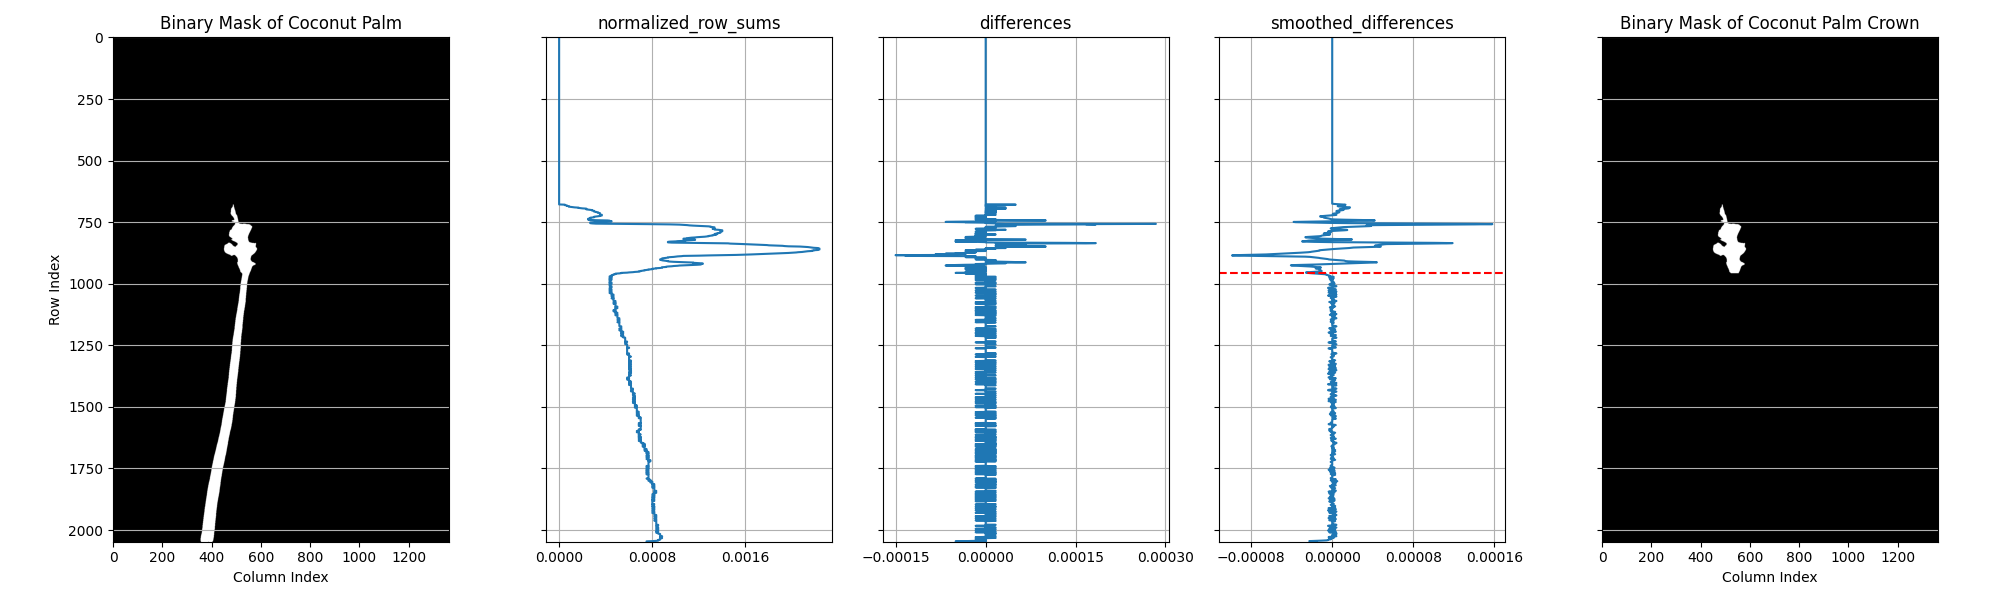

In [25]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 6), sharey=True, gridspec_kw={'width_ratios': [3, 2, 2, 2, 3]})

# Plot the original binary mask
ax1.imshow(mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)
ax1.xaxis.grid(False)
ax1.yaxis.grid(True)

ax2.plot(normalized_row_sums, row_indices)
ax2.set_title("normalized_row_sums")
ax2.grid(True)
ax2.xaxis.set_major_locator(plt.MaxNLocator(4))

ax3.plot(differences, row_indices)
ax3.set_title("differences")
ax3.grid(True)
ax3.xaxis.set_major_locator(plt.MaxNLocator(4))

ax4.plot(gaussian_smoothed_differences, row_indices)
ax4.set_title("smoothed_differences")
ax4.grid(True)
ax4.axhline(cut_line, color='red', linestyle='--')
ax4.xaxis.set_major_locator(plt.MaxNLocator(4))


ax5.imshow(crown_mask, cmap='gray')
ax5.set_title("Binary Mask of Coconut Palm Crown")
# ax5.set_ylabel("Row Index")
ax5.set_xlabel("Column Index")
# ax1.yaxis.set_inverted(True)
ax5.xaxis.grid(False)
ax5.yaxis.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# important: create a copy of mask instead of a view
crown_mask = mask.copy()

# erase mask pixels on rows below (greater than) cut_line
crown_mask[cut_line+1:, :] = 0
ic(crown_mask);


# nonzero_row_indices = np.where(crown_mask.any(axis=1))[0]
# ic(nonzero_row_indices)
# nonzero_col_indices = np.where(crown_mask.any(axis=0))[0]
# ic(nonzero_col_indices)

# ymin = nonzero_row_indices[0].item()
# ymax = nonzero_row_indices[-1].item()

# xmin = nonzero_col_indices[0].item()
# xmax = nonzero_col_indices[-1].item()

In [ ]:
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(crown_mask, cmap='gray')
plt.show()

In [ ]:
my_img = cv2.imread(image_paths[0])
my_img = cv2.cvtColor(my_img, cv2.COLOR_RGB2BGR)
contours, hierarchy = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(my_img, [cnt], 0, (0, 255, 0), 1)
    # Draw convex hull in red
    cv2.drawContours(my_img, [hull], 0, (0, 0, 255), 1)
    
    hull_indices = cv2.convexHull(cnt, returnPoints=False)
    defects = cv2.convexityDefects(cnt, hull_indices)
    
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i,0]
        start = tuple(cnt[s][0])
        end = tuple(cnt[e][0])
        far = tuple(cnt[f][0])
        
        # Optional: Filter by depth to ignore small noise
        if d > 1:
            cv2.line(img=my_img, pt1=start, pt2=far, color=(255, 0, 0), thickness=3)
            cv2.line(img=my_img, pt1=end, pt2=far, color=(255, 0, 0), thickness=3)
            # cv2.circle(img=my_img, center=far, radius=5, color=(0, 0, 255), thickness=-1)
    
fig, ax1 = plt.subplots(1, 1)
ax1.imshow(my_img)
plt.show()


In [ ]:
ic(start, end, far)
len(contours)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
    gridspec_kw={'width_ratios': [3, 1]})

# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.set_ylim(ymin, ymax)
ax1.set_xlim(xmin, xmax)
ax1.yaxis.set_inverted(True)


# Plot the row sums
# We plot (row_sums) on X and (row_indices) on Y to align with the image
# ax2.plot(row_sums, row_indices)
# ax2.set_title("Row Sums")
# ax2.set_xlabel("Sum Value (pixels)")
# ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# 1. Load and process image
img = cv2.imread('shape.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)

# 2. Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# 3. Calculate and draw hull for each contour
for cnt in contours:
    hull = cv2.convexHull(cnt)
    # Draw original contour in green
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    # Draw convex hull in red
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
nonzero_row_indices = np.where(crown_mask.any(axis=1))[0]
ic(nonzero_row_indices)
nonzero_col_indices = np.where(crown_mask.any(axis=0))[0]
ic(nonzero_col_indices)

ymin = nonzero_row_indices[0].item()
ymax = nonzero_row_indices[-1].item()

xmin = nonzero_col_indices[0].item()
xmax = nonzero_col_indices[-1].item()

In [ ]:
# import cv2
# import numpy as np

# # Load and binarize image
# img = cv2.imread('image.png')
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# ret, thresh = cv2.threshold(gray, 127, 255, 0)

# Find contours
# contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(crown_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    # Calculate convex hull
    hull = cv2.convexHull(cnt)
    
    # Draw original contour (green) and hull (red)
    cv2.drawContours(img, [cnt], 0, (0, 255, 0), 2)
    cv2.drawContours(img, [hull], 0, (0, 0, 255), 3)

cv2.imshow('Convex Hull', img)
cv2.waitKey(0)


In [ ]:
# Plot the original binary mask
ax1.imshow(crown_mask, cmap='gray')
ax1.set_title("Binary Mask of Coconut Palm")
ax1.set_ylabel("Row Index")
ax1.set_xlabel("Column Index")
ax1.yaxis.set_inverted(True)


In [ ]:
ic(type(row_sums))  
delta = np.diff(row_sums.astype(np.int32))
ic(type(delta))
plt.plot(delta
plt.title("Difference of Row Sums")
plt.xlabel("Row Index")
plt.ylabel("Difference in Sum Value")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Causes huge numbers
a = np.array([5, 10, 2, 8], dtype=np.uint8)
print(np.diff(a)) 
# Output: [  5 246   6] (10-2 is 8, but 2-10 wraps)

# Correct approach
b = a.astype(np.int16)
print(np.diff(b)) 
# Output: [ 5 -8  6]


In [ ]:
diff